In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne

# path_to_folder = r"C:\Users\clara\Desktop\special_course\ds003838"
path_to_folder = r"C:\Users\cdd\Documents\Uni\Special_course\ds003838-download"

subnums = np.arange(32, 99, 1)
subnums = np.delete(subnums, np.where((subnums == 37) | (subnums == 66) | (subnums == 94))) # remove subjects with missing data
subject_folders = [f'sub-0{i}' for i in subnums]


I am using mne library: https://mne.tools/stable/auto_tutorials/intro/10_overview.html#sphx-glr-auto-tutorials-intro-10-overview-py

In [2]:
# Load the EEGLAB .set file
subject = 33
file_path = os.path.join(path_to_folder, f"sub-{subject:03d}", "eeg", f"sub-{subject:03d}_task-memory_eeg.set")
raw = mne.io.read_raw_eeglab(file_path, preload=True)

c:\Users\cdd\AppData\Local\anaconda3\envs\special_course_env\lib\site-packages\pymatreader\utils.py:168: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(
C:\Users\cdd\AppData\Local\Temp\ipykernel_1304\3654668479.py:4: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(file_path, preload=True)


In [3]:

# Display basic information
print("EEG File Information:")
print(raw.info)
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]} seconds")

# Display channel names (columns)
print("\nChannel Names:")
print(raw.ch_names)

# Display first few lines of data
print("\nFirst 5 time points of data:")
data, times = raw[:, :5]  # Get first 5 time points for all channels
print("Timestamps:", times)
print("Data shape:", data.shape)
print("Data sample:")
print(data[:5, :])  # Show first 5 channels

EEG File Information:
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 63 EEG
 custom_ref_applied: False
 dig: 66 items (3 Cardinal, 63 EEG)
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 63
 projs: []
 sfreq: 1000.0 Hz
>
Number of channels: 63
Sampling frequency: 1000.0 Hz
Duration: 8446.879 seconds

Channel Names:
['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']

First 5 time points of data:
Timestamps: [0.    0.001 0.002 0.003 0.004]
Data shape: (63, 5)
Data sample:
[[-0.01290253 -0.01291264 -0.01290864 -0.01289931 -0.01289194]
 [ 0

In [4]:
events, event_ids = mne.events_from_annotations(raw)
print(f'Event IDs: {event_ids}')
print("Sample number - Ignore - event ID")
print(events[:5])  # show the first 5

Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001050', '6001051', '6001090', '6001091', '6001130', '6001131', '6002050', '6002051', '6002090', '6002091', '6002130', '6002131', '6003050', '6003051', '6003090', '6003091', '6003130', '6003131', '6004050', '6004051', '6004090', '6004091', '6004130', '6004131', '6005050', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008130', '6009090', '6009130', '6009131', '6010130', '6011130', '6012130', '6013130', 'boundary']
Event IDs: {'500105': 1, '500109': 2, '500113': 3, '500205': 4, '500209': 5, '500213': 6, '500305': 7, '500309': 8, '500313': 9, '500405': 10, '500409': 11, '500413': 12

**EPOCHS:**

**tmin** and **tmax** (the time relative to each event at which to start and end each epoch)
So we need tmin = -2
tmax = 11, 17 or 27 for load 5, 9 or 13, respectively
so we need to start the epochs when we have the eventIDs xx01xx and depending on the load we change the tmax.

These time epochs is consistent with the used for pupillometry.

´´epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2,
    tmax=0.5,
    reject=reject_criteria,
    preload=True,
)´´

**PREPROCESSING**
-	1 Hz High pass and 45 Hz Low pass filter to every recording (In thesis 4 to 8 (WHY?), Ill do it for now)
-	Re reference data
-	**TODO**: AMICA, Remove components related to eye movement
-	Subtract components mapped onto one electrode and could be distinguished from EEG signals
-	Data epoched in [-1500 3500ms] intervals
-	Artifacts removed
-	Epochs converted into CSD
-	Time-freq analysis Morlet wavelets
-	Spectral power baseline normalized 


In [5]:
raw.filter(l_freq = 4.0, h_freq = 8.0) # Bandpass filter between 4 and 8 Hz
raw.set_eeg_reference(ref_channels='average') # Set average reference, this calculates the average accross all electrodes
                                            #  and subtracts it from each channel for time t. This makes the sum of all
                                            #  channels equal to 0, which is a good reference for EEG data

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 1651 samples (1.651 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    4.0s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEEGLAB | sub-033_task-memory_eeg.set, 63 x 8446880 (8446.9 s), ~3.96 GB, data loaded>

In [6]:
annotated_codes_memory_05 = ['6001050', '6001051']
annotated_codes_memory_09 = ['6001090', '6001091']
annotated_codes_memory_13 = ['6001130', '6001131']
event_mapping_memory_05 = {code: event_ids[code] for code in annotated_codes_memory_05 if code in event_ids}
event_mapping_memory_09 = {code: event_ids[code] for code in annotated_codes_memory_09 if code in event_ids}
event_mapping_memory_13 = {code: event_ids[code] for code in annotated_codes_memory_13 if code in event_ids}
event_mapping_contorl_05 = ({'500105': event_ids['500105']} if '500105' in event_ids else {})
event_mapping_control_09 = ({'500109': event_ids['500109']} if '500109' in event_ids else {})
event_mapping_control_13 = ({'500113': event_ids['500113']} if '500113' in event_ids else {})

frontal_midline_channels = ['AFz', 'AF3', 'AF4', 'Fz', 'F1', 'F2', 'F3', 'F4', 'FC3', 'FC1', 'FC2', 'FC4', 'Cz', 'C3', 'C1', 'C2', 'C4']

tmin = -2
tmax_05 = 11
tmax_09 = 17
tmax_13 = 27
baseline=(-1, 0) # baseline correction from -1 to 0 seconds
                # h corresponded to the last second of the baseline fixation before the presentation of the first digit in a sequence

epochs_memory_05 = mne.Epochs(raw, events, event_id=event_mapping_memory_05, tmin=tmin, tmax=tmax_05, preload=True) # epochs data, but from -2 to 10 seconds insetad of [-1.5 to 3.5]
epoch_memory_09 = mne.Epochs(raw, events, event_id=event_mapping_memory_09, tmin=tmin, tmax=tmax_09, preload=True)
epoch_memory_13 = mne.Epochs(raw, events, event_id=event_mapping_memory_13, tmin=tmin, tmax=tmax_13, preload=True)

epochs_control_05 = mne.Epochs(raw, events, event_id=event_mapping_contorl_05, tmin=tmin, tmax=tmax_05, preload=True)
epoch_control_09 = mne.Epochs(raw, events, event_id=event_mapping_control_09, tmin=tmin, tmax=tmax_09, preload=True)
epoch_control_13 = mne.Epochs(raw, events, event_id=event_mapping_control_13, tmin=tmin, tmax=tmax_13, preload=True)

Not setting metadata
36 matching events found


Setting baseline interval to [-2.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 36 events and 13001 original time points ...
0 bad epochs dropped
Not setting metadata
36 matching events found
Setting baseline interval to [-2.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 36 events and 19001 original time points ...
0 bad epochs dropped
Not setting metadata
36 matching events found
Setting baseline interval to [-2.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 36 events and 29001 original time points ...
0 bad epochs dropped
Not setting metadata
18 matching events found
Setting baseline interval to [-2.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 18 events and 13001 original time points ...
0 bad epochs dropped
Not se

In [7]:
# Compute Compute CSD 
# THIS IS COMMENTED OUT IN THESIS, i HAVE NOT RUN THIS PART YET

epochs_memory_05_csd =  mne.preprocessing.compute_current_source_density(
    epochs_memory_05, # Copy the epochs to avoid modifying the original data
    sphere='auto',
    lambda2 = 1e-5,
    stiffness=4,
    n_legendre_terms=50,
    copy=True,
    verbose=True
)
epoch_memory_09_csd = mne.preprocessing.compute_current_source_density(
    epoch_memory_09, sphere='auto', lambda2 = 1e-5, stiffness=4, n_legendre_terms=50, copy=True, verbose=True
)
epoch_memory_13_csd = mne.preprocessing.compute_current_source_density(
    epoch_memory_13, sphere='auto', lambda2 = 1e-5, stiffness=4, n_legendre_terms=50, copy=True, verbose=True
)                                                                         
epochs_control_05_csd = mne.preprocessing.compute_current_source_density(
    epochs_control_05, sphere='auto', lambda2 = 1e-5, stiffness=4, n_legendre_terms=50, copy=True, verbose=True
)
epoch_control_09_csd = mne.preprocessing.compute_current_source_density(
    epoch_control_09, sphere='auto', lambda2 = 1e-5, stiffness=4, n_legendre_terms=50, copy=True, verbose=True
)
epoch_control_13_csd = mne.preprocessing.compute_current_source_density(
    epoch_control_13, sphere='auto', lambda2 = 1e-5, stiffness=4, n_legendre_terms=50, copy=True, verbose=True
)

Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm
Fitted sphere radius:         100.0 mm
Origin head coordinates:      -0.0 -0.0 0.0 mm
Origin device coordinates:    -0.0 -0.0 0.0 mm


In [8]:
print(f"Subject {subject:03d}:")
print(f"    load 5: {len(epochs_memory_05)} memory epochs, {len(epochs_control_05)} control epochs")
print(f"    load 9: {len(epoch_memory_09)} memory epochs, {len(epoch_control_09)} control epochs")
print(f"    load 13: {len(epoch_memory_13)} memory epochs, {len(epoch_control_13)} control epochs")

Subject 033:
    load 5: 36 memory epochs, 18 control epochs
    load 9: 36 memory epochs, 18 control epochs
    load 13: 36 memory epochs, 18 control epochs


In [12]:
log_values = np.logspace(np.log10(3), np.log10(12), 45)
print(log_values)

[ 3.          3.09602484  3.19512327  3.29739367  3.40293757  3.51185974
  3.62426833  3.74027493  3.85999469  3.98354648  4.11105295  4.24264069
  4.37844032  4.51858666  4.66321885  4.81248046  4.96651968  5.12548943
  5.28954753  5.45885685  5.63358546  5.81390684  6.          6.19204968
  6.39024654  6.59478734  6.80587513  7.02371949  7.24853667  7.48054986
  7.71998939  7.96709297  8.22210591  8.48528137  8.75688063  9.03717332
  9.32643769  9.62496092  9.93303936 10.25097886 10.57909506 10.91771369
 11.26717093 11.62781369 12.        ]


In [9]:
def calculate_theta_power(epochs, channels, baseline):
    """Calculate theta power and SEM for given epochs."""
    freqs = np.arange(4, 9, 1)  # Theta band (4 to 8 Hz), but paper does 1 to 45Hz
                                # 1 Hz steps, like in the paper
                                    # For this low frequency range, maybe it is better to use Hilbert transform instead of Morlet wavelets?
    n_cycles = [3.30464978,  3.41292571,  3.52474928, 3.64023672,  3.75950806] # TODO: Ask why these vales?
                                                                            # On paper it says 45 vvalues from 3 to 12 logarithmically spaced
                                                                            # n_cycles = np.logspace(np.log10(3), np.log10(12), len(freqs))

    # Time-frequency analysis           
    power_theta = mne.time_frequency.tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False)
                                                            # on thesis average True bc we average accross trials, but here we want to keep it False to get the power for each trial
    power_theta.apply_baseline(baseline=baseline, mode='percent')

    # Average over frequencies, -	Spectral power baseline normalized 
    # theta_power_mean = power.data.mean(axis=1)  # Shape: from (n_channels, n_frequencies, n_times) to (n_channels, n_times)
    # theta_power_sem = power.data.std(axis=1) / np.sqrt(power.data.shape[1])  # SEM across freqs

    # return theta_power_mean, theta_power_sem
    return power_theta


In [10]:
# First, calculate theta power for all 6 conditions (if you haven't already):
power_mem_05 = calculate_theta_power(epochs_memory_05, frontal_midline_channels, baseline)
power_mem_09 = calculate_theta_power(epoch_memory_09, frontal_midline_channels, baseline)
power_mem_13 = calculate_theta_power(epoch_memory_13, frontal_midline_channels, baseline)

power_ctrl_05 = calculate_theta_power(epochs_control_05, frontal_midline_channels, baseline)
power_ctrl_09 = calculate_theta_power(epoch_control_09, frontal_midline_channels, baseline)
power_ctrl_13 = calculate_theta_power(epoch_control_13, frontal_midline_channels, baseline)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   11.4s


Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   26.5s


Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


...

Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    7.8s


Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:   13.0s


Applying baseline correction (mode: percent)


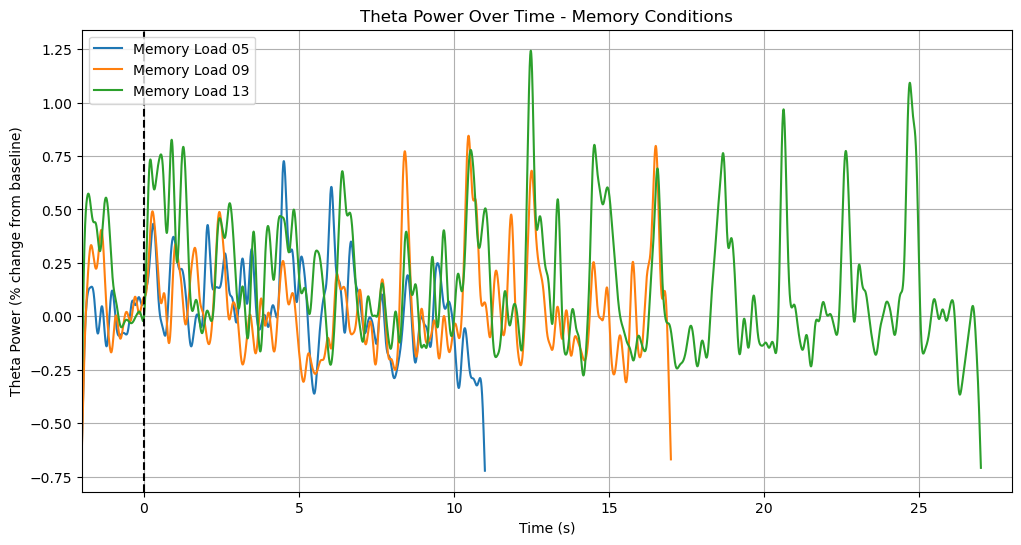

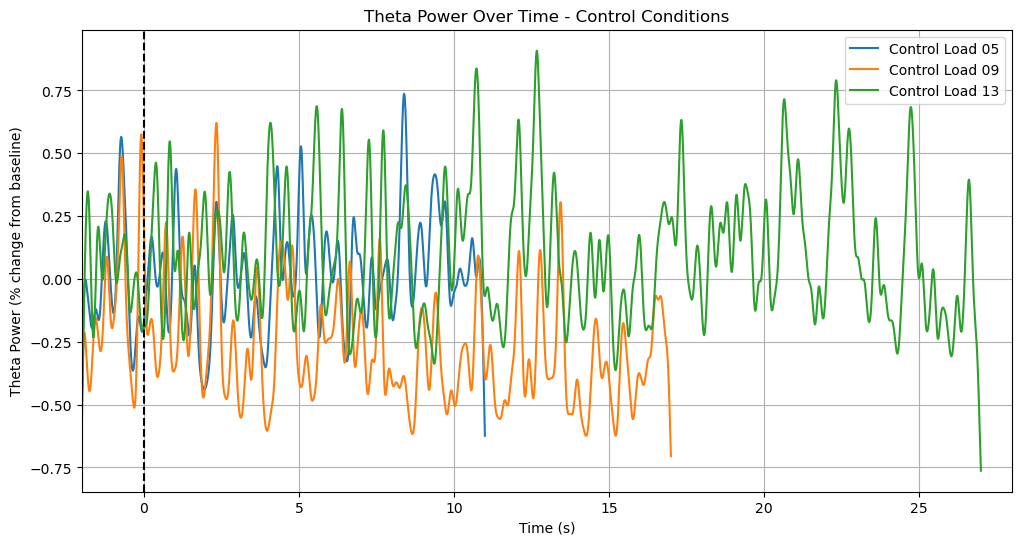

In [11]:
# Get time axis (shared across all TFRs)
times_05 = power_mem_05.times  
times_09 = power_mem_09.times  
times_13 = power_mem_13.times  

# Helper function: Average theta power over selected channels and frequencies
def average_theta_power(power_obj, channels):
    # Get indices for the frontal midline channels
    ch_indices = [power_obj.ch_names.index(ch) for ch in channels if ch in power_obj.ch_names]
    
    # Average over selected channels and frequencies
    data_avg = power_obj.data[ch_indices, :, :].mean(axis=0).mean(axis=0)  # shape: (n_times,)
    return data_avg

# Calculate the average theta power over time
mem_05_avg = average_theta_power(power_mem_05, frontal_midline_channels)
mem_09_avg = average_theta_power(power_mem_09, frontal_midline_channels)
mem_13_avg = average_theta_power(power_mem_13, frontal_midline_channels)

ctrl_05_avg = average_theta_power(power_ctrl_05, frontal_midline_channels)
ctrl_09_avg = average_theta_power(power_ctrl_09, frontal_midline_channels)
ctrl_13_avg = average_theta_power(power_ctrl_13, frontal_midline_channels)

# Plot Memory Conditions
plt.figure(figsize=(12, 6))
plt.plot(times_05, mem_05_avg, label='Memory Load 05')
plt.plot(times_09, mem_09_avg, label='Memory Load 09')
plt.plot(times_13, mem_13_avg, label='Memory Load 13')
plt.title('Theta Power Over Time - Memory Conditions')
plt.xlabel('Time (s)')
plt.ylabel('Theta Power (% change from baseline)')
plt.legend()
plt.grid(True)
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-2, 28)
plt.show()

# Plot Control Conditions
plt.figure(figsize=(12, 6))
plt.plot(times_05, ctrl_05_avg, label='Control Load 05')
plt.plot(times_09, ctrl_09_avg, label='Control Load 09')
plt.plot(times_13, ctrl_13_avg, label='Control Load 13')
plt.title('Theta Power Over Time - Control Conditions')
plt.xlabel('Time (s)')
plt.ylabel('Theta Power (% change from baseline)')
plt.legend()
plt.grid(True)
plt.axvline(0, color='k', linestyle='--')
plt.xlim(-2, 28)
plt.show()
